# Hospital Readmissions Analysis

## Data Loading Initial Inspection

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv("data/cms_hospital_readmissions.csv")

In [6]:
df.head()

,Facility Name,Facility ID,State,Measure Name,Number of Discharges,Footnote,Excess Readmission Ratio,Predicted Readmission Rate,Expected Readmission Rate,Number of Readmissions,Start Date,End Date
0,SOUTHEAST HEALTH MEDICAL CENTER,10001,AL,READM-30-HIP-KNEE-HRRP,NaN,NaN,0.9875,4.5734,4.6311,Too Few to Report,07/01/2021,06/30/2024
1,SOUTHEAST HEALTH MEDICAL CENTER,10001,AL,READM-30-CABG-HRRP,137.0,NaN,0.9531,10.3960,10.9078,13,07/01/2021,06/30/2024
2,SOUTHEAST HEALTH MEDICAL CENTER,10001,AL,READM-30-AMI-HRRP,273.0,NaN,0.9370,13.2998,14.1948,33,07/01/2021,06/30/2024
3,SOUTHEAST HEALTH MEDICAL CENTER,10001,AL,READM-30-COPD-HRRP,122.0,NaN,0.9823,16.6384,16.9389,19,07/01/2021,06/30/2024
4,SOUTHEAST HEALTH MEDICAL CENTER,10001,AL,READM-30-PN-HRRP,507.0,NaN,0.9871,15.7529,15.9591,79,07/01/2021,06/30/2024


### Initial Data Inspection

Review the dataset's dimensions, column names, data types, missing values, and summary statistics before cleaning.

In [7]:
df.shape

(18330, 12)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18330 entries, 0 to 18329
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Facility Name               18330 non-null  object 
 1   Facility ID                 18330 non-null  int64  
 2   State                       18330 non-null  object 
 3   Measure Name                18330 non-null  object 
 4   Number of Discharges        8242 non-null   float64
 5   Footnote                    6987 non-null   float64
 6   Excess Readmission Ratio    11720 non-null  float64
 7   Predicted Readmission Rate  11720 non-null  float64
 8   Expected Readmission Rate   11720 non-null  float64
 9   Number of Readmissions      11720 non-null  object 
 10  Start Date                  18330 non-null  object 
 11  End Date                    18330 non-null  object 
dtypes: float64(5), int64(1), object(6)
memory usage: 1.7+ MB


In [9]:
df.columns

Index(['Facility Name', 'Facility ID', 'State', 'Measure Name',
       'Number of Discharges', 'Footnote', 'Excess Readmission Ratio',
       'Predicted Readmission Rate', 'Expected Readmission Rate',
       'Number of Readmissions', 'Start Date', 'End Date'],
      dtype='object')

In [10]:
df.describe()

,Facility ID,Number of Discharges,Footnote,Excess Readmission Ratio,Predicted Readmission Rate,Expected Readmission Rate
count,18330.000000,8242.000000,6987.000000,11720.000000,11720.000000,11720.000000
mean,262031.979378,283.416282,4.550308,1.001777,14.981461,14.947978
std,164868.122655,270.929023,6.181702,0.082050,4.763655,4.620865
min,10001.000000,0.000000,1.000000,0.469800,1.908000,3.087600
25%,110069.000000,117.000000,1.000000,0.958200,12.529550,12.623750
50%,250048.000000,198.000000,5.000000,0.997300,15.860150,15.856550
75%,390138.000000,358.000000,5.000000,1.042300,18.418500,18.500925
max,670342.000000,3672.000000,29.000000,1.629700,28.164300,26.865400


### Missing Values

Evaluate missing values to determine whether they represent unavailable data, suppressed values, or other reporting conditions.

In [11]:
df.isna().sum()

Facility Name                     0
Facility ID                       0
State                             0
Measure Name                      0
Number of Discharges          10088
Footnote                      11343
Excess Readmission Ratio       6610
Predicted Readmission Rate     6610
Expected Readmission Rate      6610
Number of Readmissions         6610
Start Date                        0
End Date                          0
dtype: int64

In [20]:
(df.isna().sum()  * 100 / len(df)).round(2)

Facility Name                  0.00
Facility ID                    0.00
State                          0.00
Measure Name                   0.00
Number of Discharges          55.04
Footnote                      61.88
Excess Readmission Ratio      36.06
Predicted Readmission Rate    36.06
Expected Readmission Rate     36.06
Number of Readmissions        36.06
Start Date                     0.00
End Date                       0.00
dtype: float64

In [21]:
df["Footnote"].value_counts(dropna=False)

Footnote
NaN     11343
5.0      3255
1.0      3150
29.0      377
7.0       205
Name: count, dtype: int64

In [22]:
df["Number of Readmissions"].value_counts(dropna=False)

Number of Readmissions
NaN                  6610
Too Few to Report    3683
11                    318
14                    290
12                    263
                     ... 
137                     1
252                     1
212                     1
263                     1
288                     1
Name: count, Length: 291, dtype: int64

In [23]:
df["Number of Readmissions"].unique()[:20]

array(['Too Few to Report', '13', '33', '19', '79', '136', nan, '17',
       '35', '30', '29', '105', '88', '37', '16', '12', '11', '56', '46',
       '25'], dtype=object)

In [24]:
df.loc[
    df["Excess Readmission Ratio"].isna(),
    ["Number of Discharges", "Footnote", "Number of Readmissions"]
].head(20)

,Number of Discharges,Footnote,Number of Readmissions
6,NaN,5.0,NaN
7,NaN,1.0,NaN
19,NaN,1.0,NaN
21,NaN,1.0,NaN
23,NaN,5.0,NaN
24,NaN,5.0,NaN
26,NaN,1.0,NaN
27,NaN,5.0,NaN
28,NaN,1.0,NaN
29,NaN,1.0,NaN


**Initial observation:** Missing values appear to be systematic rather than random. Readmission-related measures share the same missing-value count, and many unavailable measures are associated with CMS footnote codes. Missing discharge counts do not necessarily indicate that readmission metrics are unavailable.

In [25]:
df.groupby("Footnote", dropna=False).agg(
    total_records=("Facility ID", "count"),
    missing_readmission_ratio=("Excess Readmission Ratio", lambda x: x.isna().sum())
)

,total_records,missing_readmission_ratio
Footnote,,
1.0,3150,3150
5.0,3255,3255
7.0,205,205
29.0,377,0
NaN,11343,0


**Finding** All 6,610 missing readmission rates are associated with CMS footnote codes 1, 5, or 7. Records with footnote 29 and records without a footnote contain reported readmission ratios. This indicates that missing readmission measures are systematic and associated with CMS reporting conditions rather than random missingness. 

In [26]:
df.groupby("Footnote", dropna=False).agg(
    total_records=("Facility ID", "count"),
    missing_discharges=("Number of Discharges", lambda x: x.isna().sum()),
    missing_readmission_ratio=("Excess Readmission Ratio", lambda x: x.isna().sum())
)

,total_records,missing_discharges,missing_readmission_ratio
Footnote,,,
1.0,3150,3150,3150
5.0,3255,3255,3255
7.0,205,0,205
29.0,377,138,0
NaN,11343,3545,0


## Data Cleaning

In [27]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

In [28]:
df.columns

Index(['facility_name', 'facility_id', 'state', 'measure_name',
       'number_of_discharges', 'footnote', 'excess_readmission_ratio',
       'predicted_readmission_rate', 'expected_readmission_rate',
       'number_of_readmissions', 'start_date', 'end_date'],
      dtype='object')

In [29]:
df["facility_id"] = df["facility_id"].astype(str)

In [31]:
df["start_date"] = pd.to_datetime(df["start_date"])
df["end_date"] = pd.to_datetime(df["end_date"])

In [32]:
df[["start_date", "end_date"]].dtypes

start_date    datetime64[ns]
end_date      datetime64[ns]
dtype: object

In [33]:
df["number_of_readmissions"].unique()[:30]

array(['Too Few to Report', '13', '33', '19', '79', '136', nan, '17',
       '35', '30', '29', '105', '88', '37', '16', '12', '11', '56', '46',
       '25', '23', '38', '43', '32', '68', '27', '42', '22', '65', '20'],
      dtype=object)

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18330 entries, 0 to 18329
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   facility_name               18330 non-null  object        
 1   facility_id                 18330 non-null  object        
 2   state                       18330 non-null  object        
 3   measure_name                18330 non-null  object        
 4   number_of_discharges        8242 non-null   float64       
 5   footnote                    6987 non-null   float64       
 6   excess_readmission_ratio    11720 non-null  float64       
 7   predicted_readmission_rate  11720 non-null  float64       
 8   expected_readmission_rate   11720 non-null  float64       
 9   number_of_readmissions      11720 non-null  object        
 10  start_date                  18330 non-null  datetime64[ns]
 11  end_date                    18330 non-null  datetime64

In [35]:
df["number_of_readmissions"].value_counts(dropna=False). head(10)

number_of_readmissions
NaN                  6610
Too Few to Report    3683
11                    318
14                    290
12                    263
15                    243
13                    236
17                    218
18                    213
19                    213
Name: count, dtype: int64

In [36]:
(df["number_of_readmissions"] == "Too Few to Report").sum()

np.int64(3683)

In [37]:
df["number_of_readmissions"] = pd.to_numeric(
    df["number_of_readmissions"],
    errors="coerce"
)

In [38]:
df["number_of_readmissions"].dtype

dtype('float64')

In [40]:
df["number_of_readmissions"].isna().sum()

np.int64(10293)

**Cleaning note:** `number_of_readmissions` contained 3,683 `"Too Few to Report"` values in addition to 6,610 existing missing values. The column was converted to numeric using `errors="coerce"`, representing suppressed counts as missing rather than zero. After conversion, 10,293 values are missing.

In [41]:
df.duplicated().sum()

np.int64(0)

In [43]:
df["facility_id"].nunique()

3055

In [42]:
df["measure_name"].value_counts()

measure_name
READM-30-HIP-KNEE-HRRP    3055
READM-30-CABG-HRRP        3055
READM-30-AMI-HRRP         3055
READM-30-COPD-HRRP        3055
READM-30-PN-HRRP          3055
READM-30-HF-HRRP          3055
Name: count, dtype: int64

### Cleaning Validation

Confirm the dataset structure, data types, and missing values after cleaning.

In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18330 entries, 0 to 18329
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   facility_name               18330 non-null  object        
 1   facility_id                 18330 non-null  object        
 2   state                       18330 non-null  object        
 3   measure_name                18330 non-null  object        
 4   number_of_discharges        8242 non-null   float64       
 5   footnote                    6987 non-null   float64       
 6   excess_readmission_ratio    11720 non-null  float64       
 7   predicted_readmission_rate  11720 non-null  float64       
 8   expected_readmission_rate   11720 non-null  float64       
 9   number_of_readmissions      8037 non-null   float64       
 10  start_date                  18330 non-null  datetime64[ns]
 11  end_date                    18330 non-null  datetime64

In [45]:
df.isna().sum()

facility_name                     0
facility_id                       0
state                             0
measure_name                      0
number_of_discharges          10088
footnote                      11343
excess_readmission_ratio       6610
predicted_readmission_rate     6610
expected_readmission_rate      6610
number_of_readmissions        10293
start_date                        0
end_date                          0
dtype: int64

In [46]:
df.groupby("facility_id").size().value_counts()

6    3055
Name: count, dtype: int64

In [47]:
df.describe()

,number_of_discharges,footnote,excess_readmission_ratio,predicted_readmission_rate,expected_readmission_rate,number_of_readmissions,start_date,end_date
count,8242.000000,6987.000000,11720.000000,11720.000000,11720.000000,8037.000000,18330,18330
mean,283.416282,4.550308,1.001777,14.981461,14.947978,48.750653,2021-07-01 00:00:00,2024-06-30 00:00:00
min,0.000000,1.000000,0.469800,1.908000,3.087600,11.000000,2021-07-01 00:00:00,2024-06-30 00:00:00
25%,117.000000,1.000000,0.958200,12.529550,12.623750,19.000000,2021-07-01 00:00:00,2024-06-30 00:00:00
50%,198.000000,5.000000,0.997300,15.860150,15.856550,31.000000,2021-07-01 00:00:00,2024-06-30 00:00:00
75%,358.000000,5.000000,1.042300,18.418500,18.500925,60.000000,2021-07-01 00:00:00,2024-06-30 00:00:00
max,3672.000000,29.000000,1.629700,28.164300,26.865400,847.000000,2021-07-01 00:00:00,2024-06-30 00:00:00
std,270.929023,6.181702,0.082050,4.763655,4.620865,49.758206,NaN,NaN


## Exploratory Data Analysis

In [49]:
df["measure_name"].value_counts()

measure_name
READM-30-HIP-KNEE-HRRP    3055
READM-30-CABG-HRRP        3055
READM-30-AMI-HRRP         3055
READM-30-COPD-HRRP        3055
READM-30-PN-HRRP          3055
READM-30-HF-HRRP          3055
Name: count, dtype: int64

In [50]:
measure_labels = {
    "READM-30-HIP-KNEE-HRRP" : "Hip/Knee Replacement",
    "READM-30-CABG-HRRP" : "CABG",  
    "READM-30-AMI-HRRP" : "Heart Attack",   
    "READM-30-COPD-HRRP" : "COPD",
    "READM-30-PN-HRRP" : "Pneumonia",
    "READM-30-HF-HRRP" : "Heart Failure"
}

df["condition"] = df["measure_name"].map(measure_labels)

In [51]:
df[["measure_name", "condition"]].drop_duplicates()

,measure_name,condition
0,READM-30-HIP-KNEE-HRRP,Hip/Knee Replacement
1,READM-30-CABG-HRRP,CABG
2,READM-30-AMI-HRRP,Heart Attack
3,READM-30-COPD-HRRP,COPD
4,READM-30-PN-HRRP,Pneumonia
5,READM-30-HF-HRRP,Heart Failure


In [52]:
df["condition"]

np.int64(0)

### Readmission Outcomes by Condition

Compare predicted and expected readmission rates across the six HRRP conditions.

In [55]:
condition_summary = (
    df.groupby("condition")
    .agg(
        avg_predicted_rate=("predicted_readmission_rate", "mean"),
        avg_expected_rate=("expected_readmission_rate", "mean"),
        avg_excess_ratio=("excess_readmission_ratio", "mean"),
        reported_records=("excess_readmission_ratio", "count")
    )
    .round(2)
    .sort_values("avg_predicted_rate", ascending=False)
)

condition_summary["avg_predicted_rate"] = condition_summary["avg_predicted_rate"].round(2)
condition_summary["avg_expected_rate"] = condition_summary["avg_expected_rate"].round(2)
condition_summary["avg_excess_ratio"] = condition_summary["avg_excess_ratio"].round(4)

condition_summary

,avg_predicted_rate,avg_expected_rate,avg_excess_ratio,reported_records
condition,,,,
Heart Failure,19.38,19.35,1.0,2621
COPD,18.00,17.98,1.0,2323
Pneumonia,15.60,15.56,1.0,2715
Heart Attack,13.42,13.38,1.0,1736
CABG,10.68,10.65,1.0,878
Hip/Knee Replacement,5.49,5.46,1.0,1447


**Finding:** Average predicted 30-day readmission rates vary considerably across conditions. Heart failure has the highest average predicted readmission rate, followed by COPD, while hip/knee replacement has the lowest. Predicted and expected rate are relatively close across all six conditions.

In [54]:
median_predicted_rate = np.nanmedian(df["predicted_readmission_rate"])

round(median_predicted_rate, 2)

np.float64(15.86)

**NumPy summary:** The median predicted readmission rate across reported hospital-condition records is 15.86%.

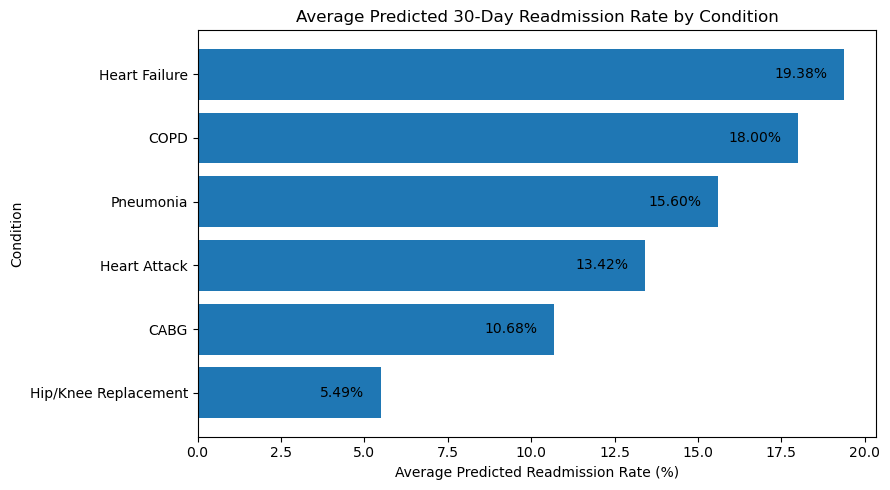

In [96]:
plt.figure(figsize=(9, 5))

plt.barh(
    condition_summary.index,
    condition_summary["avg_predicted_rate"]
)

for index, value in enumerate(condition_summary["avg_predicted_rate"]):
    plt.text(
        value - 0.5,
        index, 
        f"{value:.2f}%",
        ha="right",
        va="center"
    )

plt.xlabel("Average Predicted Readmission Rate (%)")
plt.ylabel("Condition")
plt.title("Average Predicted 30-Day Readmission Rate by Condition")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig(
    "images/predicted_readmission_rate_by_condition.png", 
    dpi=300, 
    bbox_inches="tight"
)

plt.show()

In [62]:
reported_df = df[df["excess_readmission_ratio"].notna()].copy()

In [63]:
reported_df.shape

(11720, 13)

In [64]:
reported_df["readmission_status"] = np.where(
    reported_df["excess_readmission_ratio"] > 1,
    "Higher than Expected",
    "At or Below Expected"
)

In [65]:
reported_df["readmission_status"].value_counts()

readmission_status
At or Below Expected    6077
Higher than Expected    5643
Name: count, dtype: int64

In [66]:
reported_df["readmission_status"].value_counts(normalize=True).mul(100).round(2)

readmission_status
At or Below Expected    51.85
Higher than Expected    48.15
Name: proportion, dtype: float64

**Finding:** Among the 11,720 hospital-condition records with a reported excess readmission ratio, 48.15% had higher-than-expected readmissions (ratio > 1.0), while 51.85% were at or below the expected level.

In [67]:
condition_status = (
    reported_df.groupby("condition")["readmission_status"]
    .value_counts()
    .unstack(fill_value=0)
)

condition_status        

readmission_status,At or Below Expected,Higher than Expected
condition,,
CABG,440,438
COPD,1226,1097
Heart Attack,874,862
Heart Failure,1339,1282
Hip/Knee Replacement,754,693
Pneumonia,1444,1271


In [68]:
condition_status["higher_than_expected_pct"] = (
    condition_status["Higher than Expected"]
    / condition_status.sum(axis=1)
    * 100
).round(2)

condition_status.sort_values(
    "higher_than_expected_pct",
    ascending=False
)

readmission_status,At or Below Expected,Higher than Expected,higher_than_expected_pct
condition,,,
CABG,440,438,49.89
Heart Attack,874,862,49.65
Heart Failure,1339,1282,48.91
Hip/Knee Replacement,754,693,47.89
COPD,1226,1097,47.22
Pneumonia,1444,1271,46.81


**Finding:** The share of reported hospital-condition records with higher-than-expected readmissions was relatively consistent across conditions, ranging from 46.81% for CABG. This suggests that the overall classfication of higher-than-expected readmissions does not vary substantially by condition.

In [71]:
state_summary = (
    reported_df.groupby("state")
    .agg(
        avg_excess_ratio=("excess_readmission_ratio", "mean"),
        reported_records=("excess_readmission_ratio", "count")
    )
    .sort_values("avg_excess_ratio", ascending=False)
)

state_summary["avg_excess_ratio"] = (
    state_summary["avg_excess_ratio"].round(4)
)

state_summary.head(10)

,avg_excess_ratio,reported_records
state,,
MA,1.0344,240
NJ,1.0277,272
FL,1.0229,771
IL,1.0194,491
MS,1.0141,185
AL,1.0139,247
WV,1.0115,95
NV,1.0114,94
GA,1.0114,346


In [72]:
state_summary = (
    reported_df.groupby("state")
    .agg(
        avg_excess_ratio=("excess_readmission_ratio", "mean"),
        reported_records=("excess_readmission_ratio", "count"),
        higher_than_expected_pct=(
            "excess_readmission_ratio",
            lambda x: (x>1).mean() * 100
        )
    )
)

state_summary["avg_excess_ratio"] = (
    state_summary["avg_excess_ratio"].round(4)
)

state_summary["higher_than_expected_pct"] = (
    state_summary["higher_than_expected_pct"].round(2)
)

state_summary = state_summary.sort_values(
    "higher_than_expected_pct",
    ascending=False
)

state_summary.head(10)

,avg_excess_ratio,reported_records,higher_than_expected_pct
state,,,
NJ,1.0277,272,65.44
MA,1.0344,240,62.50
MS,1.0141,185,61.08
IL,1.0194,491,57.84
FL,1.0229,771,57.46
GA,1.0114,346,55.78
CA,1.0101,1038,55.20
KY,1.0101,227,54.19
WV,1.0115,95,53.68


In [73]:
top_10_states = (
    state_summary
    .head(10)
    .sort_values("higher_than_expected_pct")
)

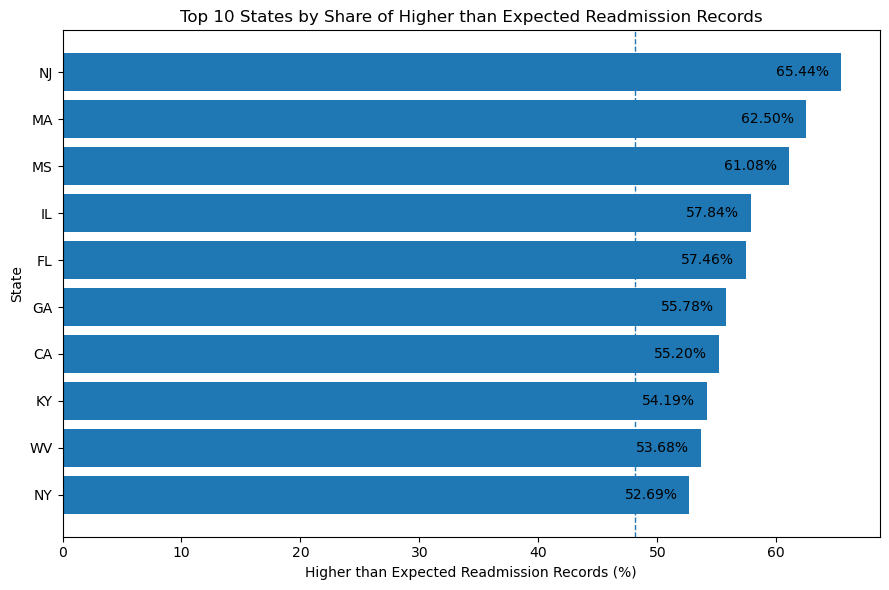

In [97]:
plt.figure(figsize=(9, 6))

plt.barh(
    top_10_states.index,
    top_10_states["higher_than_expected_pct"]
)

for index, value in enumerate(top_10_states["higher_than_expected_pct"]):
    plt.text(
        value - 1,
        index,
        f"{value:.2f}%",
        ha="right",
        va="center"
    )

plt.xlabel("Higher than Expected Readmission Records (%)")
plt.ylabel("State")
plt.title("Top 10 States by Share of Higher than Expected Readmission Records")

plt.axvline(x=48.15, linestyle="--", linewidth=1)
plt.tight_layout()

plt.savefig(
    "images/top_10_states_higher_than_expected.png", 
    dpi=300, 
    bbox_inches="tight"
)

plt.show()

**Finding:** New Jersey has the highest share of reported hospital-condition records with higher-than-expected readmissions at 65.44% , followed by Massachusetts (62.50%) and Mississippi (61.08%). Massachusetts had the highest average excess readmission ration among these states, illustrating that the average ratio and the percentage of records exceeding 1.0 capture different aspects of readmission performance.

### Hospital-Level Readmission Analysis

Examine hospitals with reported excess readmission rates to identify facilities with consistently higher-than-expected readmissions across multiple conditions.

In [79]:
hospital_summary = (
    reported_df.groupby(
        ["facility_id", "facility_name", "state"]
    )
    .agg(
        avg_excess_ratio=("excess_readmission_ratio", "mean"),
        reported_measures=("excess_readmission_ratio", "count"),
        higher_than_expected_measures=(
            "excess_readmission_ratio",
            lambda x: (x>1).sum()
        )
    )
    .reset_index()
)

hospital_summary.head()

,facility_id,facility_name,state,avg_excess_ratio,reported_measures,higher_than_expected_measures
0,100001,SHANDS JACKSONVILLE,FL,1.003060,5,3
1,100002,BETHESDA HOSPITAL EAST,FL,1.040317,6,4
2,100006,ORLANDO HEALTH,FL,1.007367,6,2
3,100007,ADVENTHEALTH ORLANDO,FL,1.142583,6,6
4,100008,BAPTIST HOSPITAL OF MIAMI,FL,1.002160,5,3


In [80]:
hospital_summary["higher_than_expected_pct"] = (
    hospital_summary["higher_than_expected_measures"]
    / hospital_summary["reported_measures"]
    * 100
).round(2)

hospital_summary["avg_excess_ratio"] = (
    hospital_summary["avg_excess_ratio"].round(4)
)

In [81]:
hospital_summary["reported_measures"].value_counts().sort_index()

reported_measures
1    202
2    239
3    484
4    599
5    662
6    647
Name: count, dtype: int64

In [82]:
hospital_analysis = hospital_summary[
    hospital_summary["reported_measures"] >= 4
].copy()

hospital_analysis.shape

(1908, 7)

In [83]:
consistently_high = hospital_analysis[
    hospital_analysis["higher_than_expected_pct"] == 100
].copy()

consistently_high.shape

(143, 7)

In [85]:
consistently_high[
    [
        "facility_name",
        "state",
        "reported_measures",
        "higher_than_expected_measures",
        "higher_than_expected_pct",
        "avg_excess_ratio"
    ]
].sort_values(
    ["reported_measures", "avg_excess_ratio"],
    ascending=[False, False]
).head(15)

,facility_name,state,reported_measures,higher_than_expected_measures,higher_than_expected_pct,avg_excess_ratio
3,ADVENTHEALTH ORLANDO,FL,6,6,100.0,1.1426
832,TUFTS MEDICAL CENTER,MA,6,6,100.0,1.1393
857,MCLAREN BAY REGION,MI,6,6,100.0,1.1384
125,HCA FLORIDA NORTHSIDE HOSPITAL,FL,6,6,100.0,1.1360
793,CAPE COD HOSPITAL,MA,6,6,100.0,1.1155
1753,JEFFERSON HEALTH- NORTHEAST,PA,6,6,100.0,1.1096
941,PARK NICOLLET METHODIST HOSPITAL,MN,6,6,100.0,1.1031
1839,BAXTER HEALTH,AR,6,6,100.0,1.0998
890,MCLAREN FLINT,MI,6,6,100.0,1.0906
2271,LEWISGALE MEDICAL CENTER,VA,6,6,100.0,1.0814


**Analysis approach:** Hospital-level comparisons were limited to facilities with at least four reported HRRP measures to provide broader condition coverage. Hospitals were considered consistently higher than expected when the excess readmissions ratio exceed 1.0 for every reported measure included in the analysis.

In [86]:
complete_measure_hospitals = hospital_summary[
    hospital_summary["reported_measures"] == 6
].copy()

complete_measure_hospitals.shape

(647, 7)

In [87]:
all_six_high = complete_measure_hospitals[
    complete_measure_hospitals["higher_than_expected_measures"] == 6
].copy()

all_six_high.shape

(17, 7)

In [88]:
all_six_high_pct = (
    len(all_six_high)
    / len(complete_measure_hospitals)
    * 100
)

round(all_six_high_pct, 2)

2.63

**Finding:** Among 647 hospitals with all six HRRP measures reported, 17 hospitals (2.63%) had higher-than-expected readmissions across all six measures. This indicates that consistently elevated excess readmission ratios across every measured condition were relatively uncommon among hospitals with complete reporting.

In [90]:
top_10_hospitals = (
    all_six_high
    .sort_values("avg_excess_ratio", ascending=False)
    .head(10)
    .sort_values("avg_excess_ratio")
)

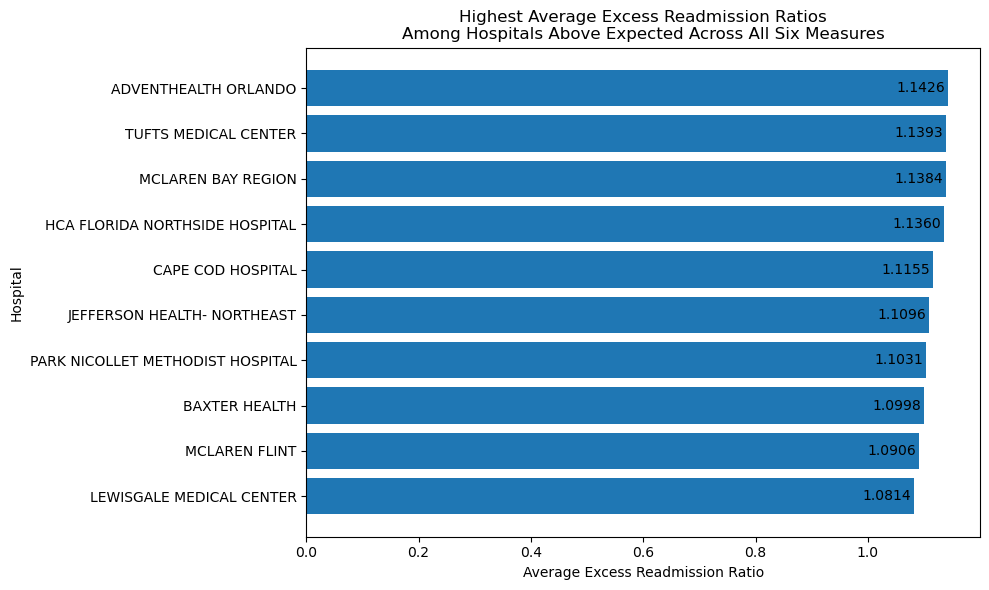

In [95]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_10_hospitals["facility_name"],
    top_10_hospitals["avg_excess_ratio"]
)

for index, value in enumerate(top_10_hospitals["avg_excess_ratio"]):
    plt.text(
        value - 0.005,
        index,
        f"{value:.4f}",
        ha="right",
        va="center"
    )

plt.xlabel("Average Excess Readmission Ratio")
plt.ylabel("Hospital")
plt.title(
    "Highest Average Excess Readmission Ratios\n"
    "Among Hospitals Above Expected Across All Six Measures"
)

plt.tight_layout()

plt.savefig(
    "images/top_10_hospitals_excess_readmission_ratio.png", 
    dpi=300, 
    bbox_inches="tight"
)

plt.show()